# 02 - Pembersihan Data & Anotasi (Sentimen & Emosi)

Notebook ini menggabungkan dua tahap sekaligus:
1. **Pembersihan Data & EDA:** Menghapus duplikat, menangani nilai kosong (Missing Values), dan melakukan Exploratory Data Analysis awal.
2. **Anotasi Data:** Menambahkan kolom **Sentiment** dan **Emotion** menggunakan perpaduan **Rating Bintang (Rules)** dan **Model NLP pra-latih (Pre-trained Models)** berbahasa Indonesia.

In [10]:
# Install library yang dibutuhkan
%pip install pandas matplotlib seaborn transformers torch tqdm ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import pipeline
from tqdm import tqdm
import re

tqdm.pandas()
sns.set_theme(style="whitegrid")

## 1. Load Dataset Hasil Scraping

In [ ]:
INPUT_CSV = "dataset\\raw_tokopedia_dataset.csv"
OUTPUT_CSV = "dataset\\annotated _tokopedia_dataset.csv"

df = pd.read_csv(INPUT_CSV)
print(f"Total Data Awal: {len(df)} baris")
display(df.head(3))

Total Data Awal: 38815 baris


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review
0,laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"barang luar biasa mantap, seller fast respon, ..."
1,laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,Untuk varian 1 TB ternyata ini 2 drive berbeda...
2,laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"Pengiriman cepat, pemasangan anti gores rapih,..."


In [22]:
file_path = "dataset/final_tokopedia_dataset.csv"

df = pd.read_csv(file_path)
df['Category'] = df['Category'].str.title()

df.to_csv(file_path, index=False)

display(df.head())
print("Kategori berhasil diubah menjadi huruf kapital!")


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"barang luar biasa mantap, seller fast respon, ...",Positive,Happy
1,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,Untuk varian 1 TB ternyata ini 2 drive berbeda...,Positive,Happy
2,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"Pengiriman cepat, pemasangan anti gores rapih,...",Positive,Happy
3,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,sudah dipakai 5 hari pengunnan nyaman dan berf...,Positive,Happy
4,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,Respon cepat dan barang sesuai....mantappp,Positive,Happy


Kategori berhasil diubah menjadi huruf kapital!


## 2. Pembersihan Data (Missing Values & Duplicates)

In [13]:
print("=== Penanganan Missing Values ===")
print("Jumlah NaN sebelum dibersihkan:")
print(df.isnull().sum())

# Isi ulasan kosong dengan string kosong, rating kosong dengan 0
df['Customer Review'] = df['Customer Review'].fillna("")
df['Customer Rating'] = df['Customer Rating'].fillna(0)

print("\n=== Penghapusan Data Duplikat ===")
total_sebelum = len(df)
# Hapus duplikat berdasarkan Nama Produk dan Ulasan (untuk mencegah ulasan yang sama ter-scrape 2x)
df = df.drop_duplicates(subset=['Product Name', 'Customer Review'], keep='first')

total_setelah = len(df)
duplikat_terhapus = total_sebelum - total_setelah
print(f"Total Data Duplikat yang Dihapus: {duplikat_terhapus} baris")
print(f"Total Data Bersih yang Siap Dianotasi: {total_setelah} baris")

=== Penanganan Missing Values ===
Jumlah NaN sebelum dibersihkan:
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     5
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
dtype: int64

=== Penghapusan Data Duplikat ===
Total Data Duplikat yang Dihapus: 10475 baris
Total Data Bersih yang Siap Dianotasi: 28340 baris


## 3. Exploratory Data Analysis (EDA) Awal

=== Top 5 Kategori Produk Terbanyak ===


Category
skincare wajah     2531
tas ransel         2515
sepatu sneakers    2499
parfum wanita      2344
jam tangan pria    2215
Name: count, dtype: int64

C:\Users\Rafie Zaidan U\AppData\Local\Temp\ipykernel_32544\905125079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Blues_d")


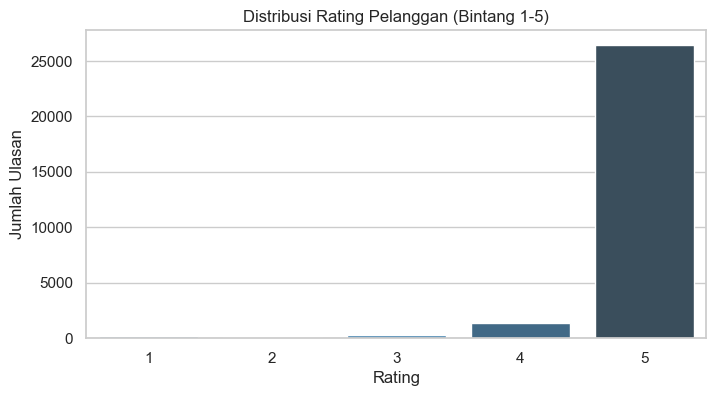

In [14]:
print("=== Top 5 Kategori Produk Terbanyak ===")
display(df['Category'].value_counts().head())

plt.figure(figsize=(8, 4))
rating_counts = df['Customer Rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Blues_d")
plt.title('Distribusi Rating Pelanggan (Bintang 1-5)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.show()

## 4. Inisialisasi Model AI & Fungsi Anotasi
*(Catatan: Membersihkan duplikat di atas sangat membantu menghemat waktu pemrosesan AI di tahap ini!)*

In [ ]:
device = 0 if torch.cuda.is_available() else -1
if device == 0:
    print("Menggunakan GPU")
else:
    print("Menggunakan CPU")

sentiment_pipeline = pipeline("text-classification", model="w11wo/indonesian-roberta-base-sentiment-classifier", device=device)
emotion_pipeline = pipeline("text-classification", model="StevenLimcorn/indonesian-roberta-base-emotion-classifier", device=device)
print("Model AI berhasil dimuat!")

MENGGUNAKAN CPU: PROSES MUNGKIN MEMAKAN WAKTU LAMA


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model AI berhasil dimuat!


In [16]:
def get_sentiment(row):
    text = str(row['Customer Review']).strip()
    try: rating = float(row['Customer Rating'])
    except: rating = 0.0
        
    if text == "" or text.lower() == "nan": return "Neutral"

    is_short = len(text) < 50
    positive_words = ['nice', 'good', 'mantap', 'bagus', 'ok', 'oke', 'keren', 'sip', 'jos', 'top', 'best']
    has_pos_word = any(w in text.lower() for w in positive_words)
    
    if rating >= 4.0 and (is_short or has_pos_word): return "Positive"
    elif rating <= 2.0 and is_short: return "Negative"

    try:
        short_text = text[:1500] 
        result = sentiment_pipeline(short_text)[0]
        label = result['label'].lower()
        if label == 'positive': return "Positive"
        elif label == 'negative': return "Negative"
        else: return "Neutral"
    except Exception: return "Neutral"

def get_emotion(row):
    text = str(row['Customer Review']).strip()
    try: rating = float(row['Customer Rating'])
    except: rating = 0.0
        
    if text == "" or text.lower() == "nan": return "None"

    is_short = len(text) < 50
    positive_words = ['nice', 'good', 'mantap', 'bagus', 'ok', 'oke', 'keren', 'sip', 'jos', 'top', 'best', 'suka']
    has_pos_word = any(w in text.lower() for w in positive_words)
    
    if rating >= 4.0 and (is_short or has_pos_word): return "Happy"
    elif rating <= 2.0 and is_short: return "Anger"

    try:
        short_text = text[:1500]
        result = emotion_pipeline(short_text)[0]
        label = result['label'].lower()
        if label == 'happy': return "Happy"
        elif label == 'sadness': return "Sadness"
        elif label == 'anger': return "Anger"
        elif label == 'fear': return "Fear"
        elif label == 'love': return "Love"
        else: return label.capitalize()
    except Exception: return "None"

## 5. Eksekusi Anotasi

In [17]:
print("Mulai mengekstraksi Sentimen...")
df['Sentiment'] = df.progress_apply(get_sentiment, axis=1)

print("Mulai mengekstraksi Emosi...")
df['Emotion'] = df.progress_apply(get_emotion, axis=1)

Mulai mengekstraksi Sentimen...


100%|██████████| 28340/28340 [06:37<00:00, 71.27it/s] 


Mulai mengekstraksi Emosi...


100%|██████████| 28340/28340 [06:37<00:00, 71.27it/s] 


## 6. Simpan Hasil Akhir

In [23]:
columns_order = [
    'Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 
    'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 
    'Sentiment', 'Emotion'
]
df = df.reindex(columns=columns_order)

df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print(f"\nBerhasil! Data final yang telah dibersihkan & di-label disimpan dalam: {OUTPUT_CSV}")
display(df.head(10))


Berhasil! Data final yang telah dibersihkan & di-label disimpan dalam: dataset\final_tokopedia_dataset.csv


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"barang luar biasa mantap, seller fast respon, ...",Positive,Happy
1,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,Untuk varian 1 TB ternyata ini 2 drive berbeda...,Positive,Happy
2,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"Pengiriman cepat, pemasangan anti gores rapih,...",Positive,Happy
3,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,sudah dipakai 5 hari pengunnan nyaman dan berf...,Positive,Happy
4,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,Respon cepat dan barang sesuai....mantappp,Positive,Happy
5,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,3,after salesnya kurang sellernya responsif tapi...,Negative,Sadness
6,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"mantap sesuai deskripsi, pengiriman cepat dan ...",Positive,Happy
7,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"Yap, sesuai deskripsi, terima kasih sudah dika...",Neutral,Happy
8,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"Barang sesuai kebutuhan, masih baru dan berjal...",Positive,Happy
9,Laptop,LENOVO LOQ 15 ARP10E RYZEN 7 7735HS RTX3050 6G...,Dilayani Tokopedia,12770010,4.9,100,18,5,"Pengiriman cepat dan teratur, CS responsif jug...",Positive,Happy


## 7. Merge dengan PRDECT-ID Dataset
Menggabungkan dataset hasil *scraping* Tokopedia dengan dataset referensi (PRDECT-ID) dan membuang data ganda (*duplicates*).

In [ ]:
import pandas as pd

# 1. Load kedua dataset
df_prdect = pd.read_csv('PRDECT-ID Dataset.csv')
df_tokopedia = pd.read_csv('dataset/final_tokopedia_dataset.csv')

print("=== Sebelum Merge ===")
print(f"Total baris PRDECT-ID: {len(df_prdect)}")
print(f"Total baris Tokopedia Baru: {len(df_tokopedia)}")

# 2. Gabungkan (Concatenate)
df_merged = pd.concat([df_prdect, df_tokopedia], ignore_index=True)
total_awal = len(df_merged)
print(f"\nTotal baris setelah digabungkan (sebelum drop duplicate): {total_awal}")

# 3. Drop Duplicates (berdasarkan ulasan dan produk)
# Kita menggunakan 'Product Name' dan 'Customer Review' sebagai indikator data yang sama persis
df_merged = df_merged.drop_duplicates(subset=['Product Name', 'Customer Review'], keep='first')
total_akhir = len(df_merged)
duplikat_dihapus = total_awal - total_akhir

print("\n=== Setelah Pembersihan Duplikat ===")
print(f"Total data duplikat yang dihapus: {duplikat_dihapus} baris")
print(f"Total data bersih saat ini: {total_akhir} baris")

# 4. Simpan hasilnya
MERGED_OUTPUT = 'dataset/final_tokopedia_dataset.csv'
df_merged.to_csv(MERGED_OUTPUT, index=False, encoding='utf-8-sig')
print(f"\nBerhasil! Dataset yang sudah di-merge tersimpan di: {MERGED_OUTPUT}")

# Tampilkan sampel 5 data terbawah
display(df_merged.tail())